<a href="https://colab.research.google.com/github/Jeffrey-AI-research/Stock-Market-Predictions-AI-Research/blob/main/Stock_Market_Predictions_AI_Research_(RF_Revision_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")

In [ ]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
# Training Machine Learning Model (Random Forest Regressor)

In [ ]:
df["Target"] = df.groupby("Ticker")["Close"].shift(-1) # Create the target variable
df = df.dropna() # Remove rows with missing target values

In [ ]:
df = df.sort_values("Date") # Sort the data by date

In [ ]:
X = df[["Open","High","Low","Close","Volume"]]
y = df["Target"]

In [ ]:
split_index = int(len(df) * 0.8) # Split data to "train(2019-2023)" and "test(2024)"

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [ ]:
# Random Forest Regressor model
model = RandomForestRegressor(n_estimators=1000,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features="sqrt",random_state=42,n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R² Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

R² Score: 0.99644733236667
Mean Absolute Error (MAE): 3.1305537843499147
Root Mean Squared Error (RMSE): 4.658274316384531


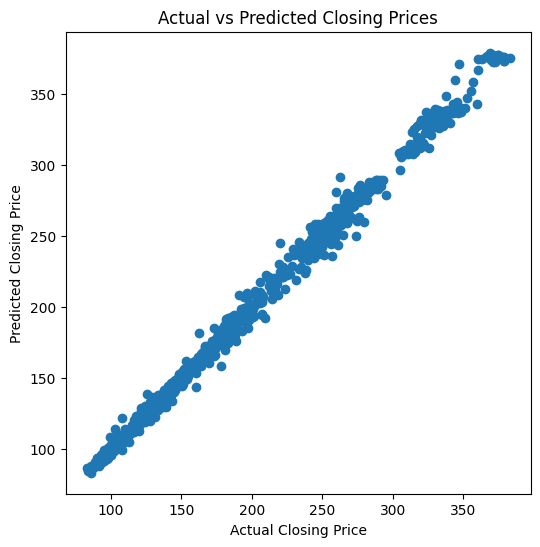

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Closing Prices")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)

  Feature  Importance
3   Close    0.361018
1    High    0.289228
2     Low    0.225492
0    Open    0.123769
4  Volume    0.000492


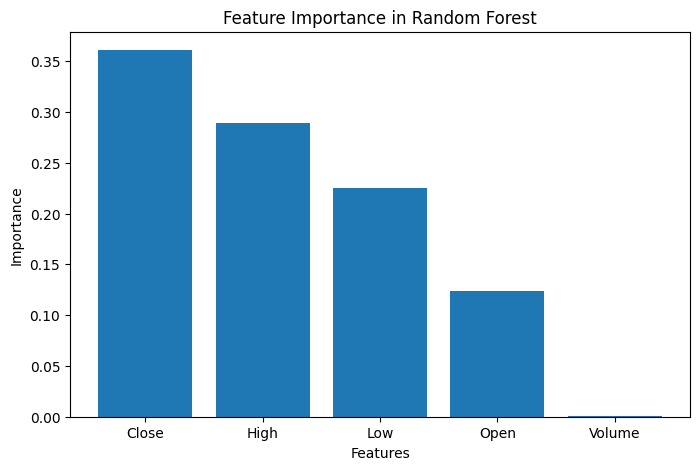

In [ ]:
# Show above importance
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])

plt.title("Feature Importance in Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

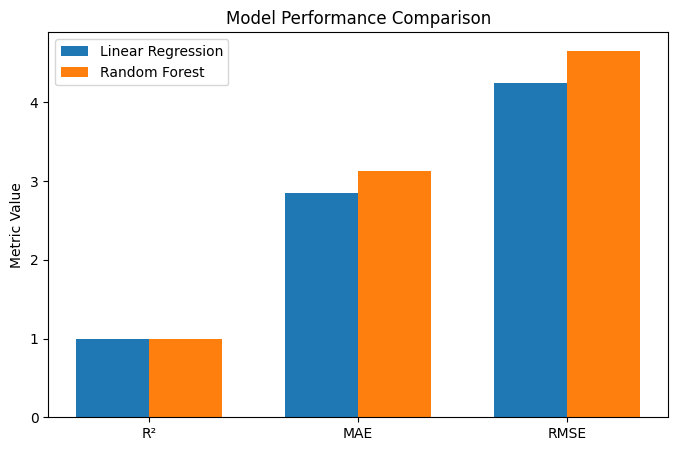

In [ ]:
metrics = ["R²", "MAE", "RMSE"]
linear = [0.9970517445839147,2.8516404094821204,4.242474419035115]
random_forest = [r2, mae, rmse]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, linear, width, label="Linear Regression")
plt.bar(x + width/2, random_forest, width, label="Random Forest")
plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Model Performance Comparison")
plt.legend()

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()